In [99]:
# data_exploration.ipynb

# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For modeling later
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# modeling used
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Display settings
pd.set_option('display.max_columns', None)


In [100]:
# Load Dataset
df = pd.read_csv("../data/raw/all_teams.csv")
print("Shape:", df.shape)
df.head()

Shape: (220260, 111)


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame
0,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,other,0.0000,0.0000,0.0000,42.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.689,0.019,0.069,0.164,0.020,0.521,0.207,0.019,0.019,0.019,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.019,0.000,0.000,0.0,0.0,0.0,1.00,1.0,1.000,0.0,0.017,0.000,0.000,0.037,0.037,0.037,0
1,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,all,0.4596,0.6408,0.6310,3600.0,37.733,2.287,2.842,8.155,1.134,22.530,16.054,2.249,2.396,2.357,41.0,12.0,13.0,66.0,2.0,1.0,0.0,14.0,2.0,18.0,16.0,39.0,51.0,4.0,8.0,30.0,16.0,19.0,8.0,44.0,8.0,1.0,1.040,0.811,0.435,1.0,0.0,1.0,68.292,53.0,54.697,4.0,0.641,0.014,0.029,2.899,3.030,2.980,22.880,2.689,1.780,4.436,0.639,12.626,8.830,2.524,2.607,2.450,21.0,10.0,6.0,37.0,1.0,1.0,0.0,5.0,1.0,8.0,15.0,20.0,30.0,7.0,14.0,32.0,17.0,11.0,7.0,16.0,12.0,3.0,0.599,1.278,0.811,1.0,0.0,0.0,36.14,31.0,30.369,5.0,0.396,0.168,0.168,2.917,2.833,2.714,0
2,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,5on5,0.4857,0.6429,0.6364,2283.0,24.802,1.693,1.724,5.513,0.739,14.650,10.681,1.656,1.803,1.764,28.0,7.0,10.0,45.0,1.0,0.0,0.0,10.0,1.0,14.0,9.0,27.0,34.0,3.0,6.0,19.0,13.0,13.0,7.0,27.0,8.0,0.0,0.882,0.811,0.000,1.0,0.0,0.0,47.292,35.0,36.697,4.0,0.355,0.000,0.000,2.048,2.180,2.130,14.729,1.793,1.117,3.001,0.406,7.737,5.946,1.633,1.711,1.559,11.0,9.0,5.0,25.0,1.0,1.0,0.0,4.0,1.0,4.0,9.0,10.0,19.0,7.0,14.0,18.0,13.0,9.0,5.0,12.0,6.0,2.0,0.498,0.689,0.606,1.0,0.0,0.0,24.14,20.0,19.369

In [101]:
# Explore Columns
df.info()
df.describe().T.head(10)

# check sample columns
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220260 entries, 0 to 220259
Columns: 111 entries, team to playoffGame
dtypes: float64(100), int64(4), object(7)
memory usage: 186.5+ MB


['team',
 'season',
 'name',
 'gameId',
 'playerTeam',
 'opposingTeam',
 'home_or_away',
 'gameDate',
 'position',
 'situation',
 'xGoalsPercentage',
 'corsiPercentage',
 'fenwickPercentage',
 'iceTime',
 'xOnGoalFor',
 'xGoalsFor',
 'xReboundsFor',
 'xFreezeFor',
 'xPlayStoppedFor',
 'xPlayContinuedInZoneFor',
 'xPlayContinuedOutsideZoneFor',
 'flurryAdjustedxGoalsFor',
 'scoreVenueAdjustedxGoalsFor',
 'flurryScoreVenueAdjustedxGoalsFor',
 'shotsOnGoalFor',
 'missedShotsFor',
 'blockedShotAttemptsFor',
 'shotAttemptsFor',
 'goalsFor',
 'reboundsFor',
 'reboundGoalsFor',
 'freezeFor',
 'playStoppedFor',
 'playContinuedInZoneFor',
 'playContinuedOutsideZoneFor',
 'savedShotsOnGoalFor',
 'savedUnblockedShotAttemptsFor',
 'penaltiesFor',
 'penalityMinutesFor',
 'faceOffsWonFor',
 'hitsFor',
 'takeawaysFor',
 'giveawaysFor',
 'lowDangerShotsFor',
 'mediumDangerShotsFor',
 'highDangerShotsFor',
 'lowDangerxGoalsFor',
 'mediumDangerxGoalsFor',
 'highDangerxGoalsFor',
 'lowDangerGoalsFor',
 '

In [102]:
# Feature Engineering

# Target variable: 1 = Win, 0 = Loss
df['win'] = (df['goalsFor'] > df['goalsAgainst']).astype(int)

# Merge Arizona with Utah due to the team relocation
df['team'] = df['team'].replace({'ARI': 'UTA'})

# Filter to keep only seasons from 2022 onward
df_recent = df[df['season'] >= 2022].reset_index(drop=True)
print("Filtered recent seasons (>= 2022):", len(df_recent))
print("Unique seasons:", df_recent['season'].unique())

# From the recent data, select only rows where situation == 'all'
df_all = df_recent[df_recent['situation'] == 'all'].reset_index(drop=True)
print("\nRows with situation == 'all':", len(df_all))
print("Unique games before cleanup:", df_all['gameId'].nunique())

# Detect and remove bad games, each game should have exactly one winner
game_win_sums = df_all.groupby('gameId')['win'].sum()

# Identify invalid games
bad_game_ids = game_win_sums[game_win_sums != 1].index
print("Bad games detected:", len(bad_game_ids))

# Remove invalid games
df_all = df_all[~df_all['gameId'].isin(bad_game_ids)].reset_index(drop=True)

# Print cleanup summary
print("\n✅ After cleanup:")
print("Total rows:", len(df_all))
print("Unique games:", df_all['gameId'].nunique())
print("Win counts:\n", df_all['win'].value_counts())

# Create performance difference features
df_all['shot_diff'] = df_all['shotsOnGoalFor'] - df_all['shotsOnGoalAgainst']
df_all['penalty_diff'] = df_all['penaltiesFor'] - df_all['penaltiesAgainst']
df_all['shotAttempt_diff'] = df_all['shotAttemptsFor'] - df_all['shotAttemptsAgainst']
df_all['faceOff_diff'] = df_all['faceOffsWonFor'] - df_all['faceOffsWonAgainst']


# Export cleaned DataFrames to ../data/processed/
df_recent.to_csv('../data/processed/recent_teams.csv', index=False)
df_all.to_csv('../data/processed/processed_teams.csv', index=False)

print("\n Saved both files to ../data/processed/:")
print(" - recent_teams.csv  → all data since 2022")
print(" - processed_teams.csv → cleaned + situation == 'all'")

# Preview cleaned data
df_all.head()


Filtered recent seasons (>= 2022): 43960
Unique seasons: [2022 2023 2024 2025]

Rows with situation == 'all': 8792
Unique games before cleanup: 4396
Bad games detected: 272

✅ After cleanup:
Total rows: 8248
Unique games: 4124
Win counts:
 win
1    4124
0    4124
Name: count, dtype: int64

 Saved both files to ../data/processed/:
 - recent_teams.csv  → all data since 2022
 - processed_teams.csv → cleaned + situation == 'all'


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff
0,NYR,2022,NYR,2022020003,NYR,TBL,HOME,20221011,Team Level,all,0.6699,0.6068,0.5904,3600.0,36.626,5.589,3.084,7.843,1.190,18.568,12.727,4.959,5.524,4.897,39.0,10.0,22.0,71.0,3.0,6.0,0.0,2.0,3.0,24.0,11.0,36.0,46.0,6.0,12.0,30.0,24.0,19.0,17.0,26.0,14.0,9.0,1.008,1.556,3.025,1.0,2.0,0.0,70.854,49.0,48.988,5.0,0.688,1.358,1.358,4.919,4.868,4.578,25.294,2.754,1.868,5.870,1.073,14.067,8.368,2.446,2.813,2.504,26.0,8.0,12.0,46.0,1.0,2.0,0.0,6.0,0.0,10.0,15.0,25.0,33.0,4.0,8.0,17.0,19.0,8.0,15.0,24.0,6.0,4.0,0.635,0.757,1.362,0.0,0.0,1.0,46.551,34.0,34.315,5.0,0.465,0.176,0.176,3.043,3.102,2.754,0,1,13.0,2.0,25.0,13.0
1,NYR,2022,NYR,2022020017,NYR,MIN,AWAY,20221013,Team Level,all,0.4152,0.4655,0.4556,3600.0,30.783,3.165,2.387,7.092,0.930,16.263,11.163,3.123,3.400,3.356,35.0,6.0,13.0,54.0,7.0,4.0,1.0,6.0,0.0,10.0,14.0,28.0,34.0,7.0,17.0,29.0,27.0,4.0,1.0,29.0,9.0,3.0,0.641,1.088,1.436,1.0,3.0,3.0,61.002,41.0,45.018,0.0,0.536,0.336,0.336,3.365,3.596,3.554,35.567,4.457,2.568,7.138,1.252,18.462,15.123,3.833,4.294,3.670,36.0,13.0,13.0,62.0,3.0,3.0,0.0,5.0,0.0,18.0,20.0,33.0,46.0,8.0,19.0,29.0,20.0,9.0,6.0,30.0,13.0,6.0,1.092,1.703,1.662,0.0,2.0,1.0,57.921,49.0,46.481,2.0,0.626,0.954,0.954,4.128,3.953,3.584,0,1,-1.0,-1.0,-8.0,0.0
2,NYR,2022,NYR,2022020023,NYR,WPG,AWAY,20221014,Team Level,all,0.4000,0.5185,0.5481,3600.0,40.542,2.814,2.906,9.682,1.407,23.631,16.561,2.725,2.863,2.773,41.0,16.0,13.0,70.0,1.0,6.0,0.0,7.0,2.0,21.0,20.0,40.0,56.0,3.0,6.0,28.0,25.0,3.0,20.0,46.0,10.0,1.0,1.318,1.288,0.208,1.0,0.0,0.0,69.733,57.0,56.422,18.0,0.645,0.430,0.430,3.029,3.073,2.982,33.758,4.221,2.192,7.402,1.079,18.976,13.131,4.109,4.173,4.062,3

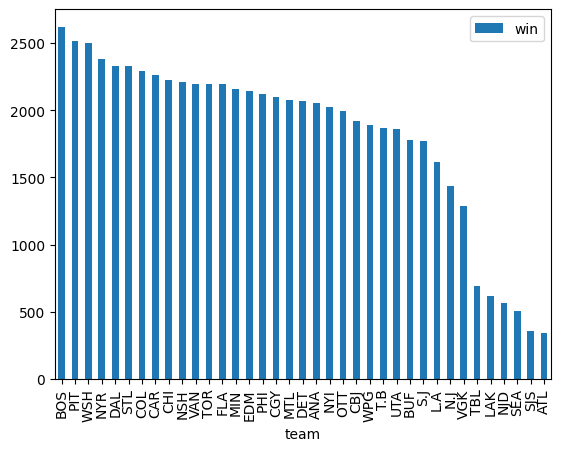

In [103]:
df_grouped = df.groupby('team')['win'].sum().reset_index().sort_values(by='win', ascending=False)

df_grouped.plot.bar(x='team', y='win')
plt.show()

Wins: 4124, Losses: 4124


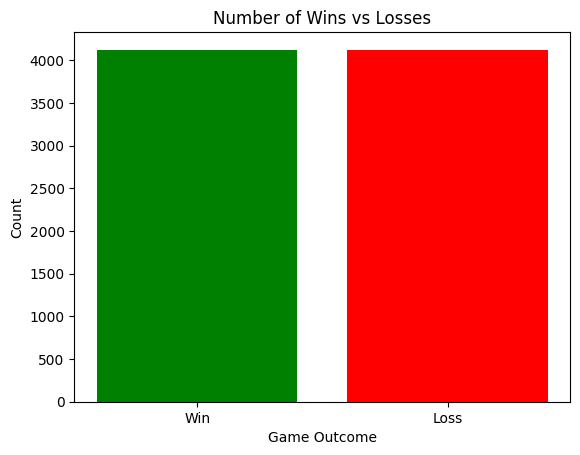

In [104]:
# Exploratory Analysis

# Count wins and losses
win_count = (df_all['win'] == 1).astype(int).sum()
loss_count = (df_all['win'] == 0).astype(int).sum()
print(f"Wins: {win_count}, Losses: {loss_count}")

# Values
categories = ['Win', 'Loss']
counts = [win_count, loss_count]

# Plot
plt.bar(categories, counts, color=['green', 'red'])
plt.title('Number of Wins vs Losses')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

In [105]:
#Final sanity checks

# Check unique teams in recent data
current_teams = df_all['team'].unique()
print("Number of unique teams:", len(current_teams))
print("Teams:", sorted(current_teams))

# Display win counts per team
print(df_all.groupby('team')['win'].agg(['sum', 'count']))

# Check for any NaN values in recent data
print("Any NaNs?", df_all.isna().sum().sum())

# Check for duplicated game-team entries in cleaned data
dup_games = df_all[df_all.duplicated(['gameId', 'team'])]
print("Duplicated rows:", len(dup_games))

Number of unique teams: 32
Teams: ['ANA', 'BOS', 'BUF', 'CAR', 'CBJ', 'CGY', 'CHI', 'COL', 'DAL', 'DET', 'EDM', 'FLA', 'LAK', 'MIN', 'MTL', 'NJD', 'NSH', 'NYI', 'NYR', 'OTT', 'PHI', 'PIT', 'SEA', 'SJS', 'STL', 'TBL', 'TOR', 'UTA', 'VAN', 'VGK', 'WPG', 'WSH']
      sum  count
team            
ANA    83    241
BOS   153    265
BUF   112    242
CAR   174    280
CBJ    88    243
CGY   112    240
CHI    74    245
COL   157    262
DAL   173    295
DET   113    243
EDM   186    309
FLA   180    310
LAK   139    252
MIN   124    245
MTL   100    238
NJD   143    264
NSH   114    251
NYI   121    251
NYR   151    267
OTT   119    252
PHI    94    237
PIT   116    243
SEA   122    254
SJS    61    238
STL   118    245
TBL   140    260
TOR   162    276
UTA   104    244
VAN   128    255
VGK   166    275
WPG   168    275
WSH   129    251
Any NaNs? 0
Duplicated rows: 0


<Axes: >

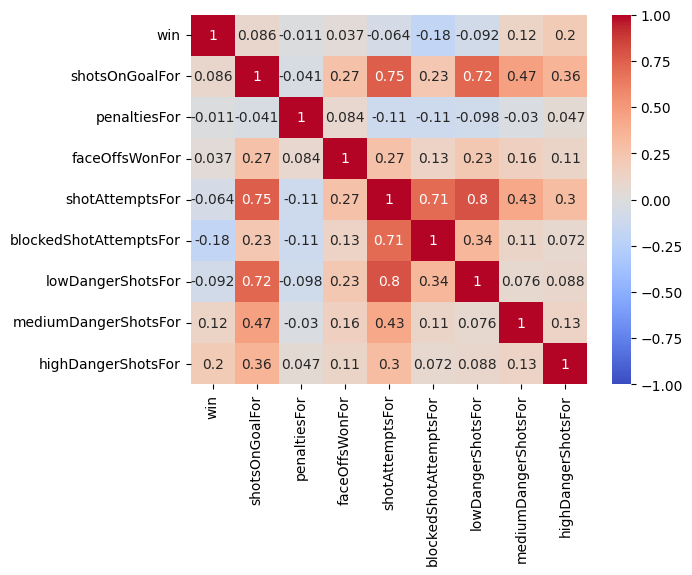

In [106]:
# Correlation heat maps
corr = df_all[['win','shotsOnGoalFor','penaltiesFor', 'faceOffsWonFor', 'shotAttemptsFor', 'blockedShotAttemptsFor', 'lowDangerShotsFor', 'mediumDangerShotsFor', 'highDangerShotsFor']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

Text(0.5, 0, 'faceOffsWonFor')

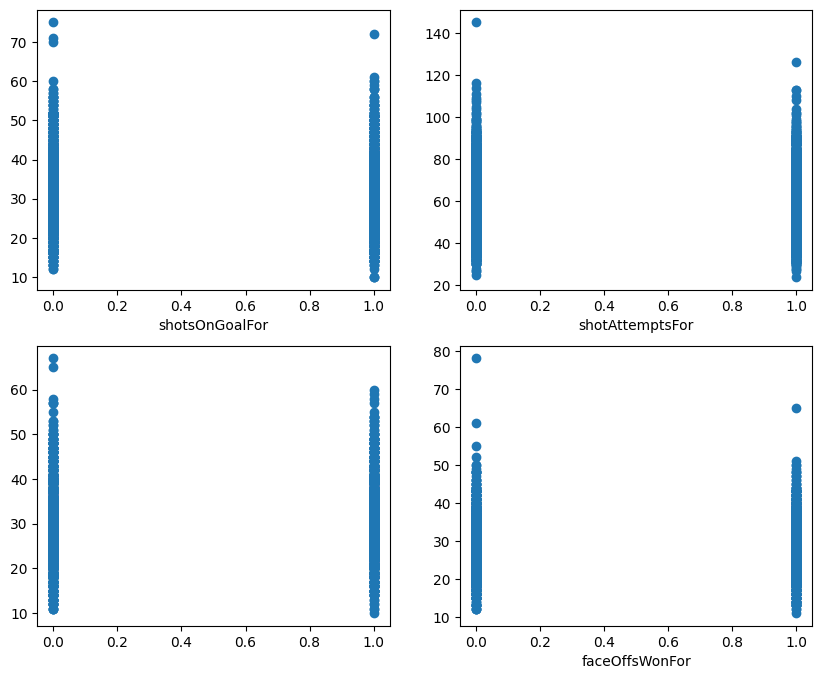

In [107]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax[0,0].scatter(df_all['win'], df_all['lowDangerShotsFor'])
ax[0,1].scatter(df_all['win'], df_all['shotAttemptsFor'])
ax[1,0].scatter(df_all['win'], df_all['shotsOnGoalFor'])
ax[1,1].scatter(df_all['win'], df_all['faceOffsWonFor'])

ax[0,0].set_xlabel('lowDangerShotsFor')
ax[0,1].set_xlabel('shotAttemptsFor')
ax[0,0].set_xlabel('shotsOnGoalFor')
ax[1,1].set_xlabel('faceOffsWonFor')

In [108]:
print(df_all.shape)

(8248, 116)


In [109]:
X = df_all.loc[:,['highDangerShotsFor', 'mediumDangerShotsFor', 'lowDangerShotsFor', 'shotAttemptsFor', 'shotsOnGoalFor', 'faceOffsWonFor', 'penaltiesFor', 'blockedShotAttemptsFor']]
y = df_all['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6406060606060606


# ------ ARYAN CODE BELOW --------

In [110]:
# This uses raw data, before aggregating them into averages. Likely not accurate, we wouldn't have this information for new games
from sklearn.model_selection import cross_val_score

df_all = pd.read_csv("../data/processed/processed_teams.csv")
X = df_all.loc[:,['highDangerShotsFor', 'mediumDangerShotsFor', 'lowDangerShotsFor', 'shotAttemptsFor', 'shotsOnGoalFor', 'faceOffsWonFor', 'penaltiesFor', 'blockedShotAttemptsFor',
                  'corsiPercentage', 'fenwickPercentage', 'shot_diff', 'shotAttempt_diff', 'xGoalsAgainst', 'xGoalsFor']]
y = df_all['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Feature importance
coefficients = lr.coef_[0]
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print(feature_importance)

scores = cross_val_score(lr, X, y, cv=5)
print(scores.mean())

train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print(train_score)
print(test_score)

Accuracy: 0.7418181818181818
                   Feature  Coefficient  Absolute_Coefficient
13               xGoalsFor     2.027709              2.027709
12           xGoalsAgainst    -0.976533              0.976533
0       highDangerShotsFor    -0.329167              0.329167
7   blockedShotAttemptsFor     0.126155              0.126155
9        fenwickPercentage    -0.122569              0.122569
3          shotAttemptsFor    -0.121049              0.121049
8          corsiPercentage    -0.108269              0.108269
2        lowDangerShotsFor     0.089976              0.089976
11        shotAttempt_diff    -0.079120              0.079120
10               shot_diff     0.058982              0.058982
6             penaltiesFor    -0.014103              0.014103
5           faceOffsWonFor     0.013691              0.013691
4           shotsOnGoalFor     0.010335              0.010335
1     mediumDangerShotsFor    -0.008013              0.008013
0.7438155723395263
0.7461351924825704
0.7

Since the dataset utilizes exact values for each game, we calculate the average of the (important) features for the model to use for predictions, as we wouldn't have the actual values before the match we would want to predict. 
We also split each feature up into different windows so the model can learn whether more recent games are important, or overall stats:
- average of last 3 games
- average of last 5 games
- average of last 10 games
- average for all games in the season

In [111]:
# Sort by team and date first
df_avg = df_all.sort_values(['playerTeam', 'gameDate']).reset_index(drop=True)

# Average for a team's last 3 games average
df_avg['xGoalsFor_last3'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=3).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last3'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=3).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last3'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=3).mean().reset_index(0, drop=True)

# For a team's last 5 games average
df_avg['xGoalsFor_last5'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=5).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last5'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=5).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last5'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=5).mean().reset_index(0, drop=True)

# For a team's last 10 games average
df_avg['xGoalsFor_last10'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=10).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last10'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=10).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last10'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=10).mean().reset_index(0, drop=True)

# For season so far
df_avg['xGoalsFor_season'] = df_avg.groupby(['playerTeam', 'season'])['xGoalsFor'].transform(lambda x: x.expanding().mean().values)
df_avg['xshotsOnGoalFor_season'] = df_avg.groupby(['playerTeam', 'season'])['shotsOnGoalFor'].transform(lambda x: x.expanding().mean().values)
df_avg['xGoalsAgainst_season'] = df_avg.groupby(['playerTeam', 'season'])['xGoalsAgainst'].transform(lambda x: x.expanding().mean().values)

df_avg.head(10)

,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff,xGoalsFor_last3,shotsOnGoalFor_last3,xGoalsAgainst_last3,xGoalsFor_last5,shotsOnGoalFor_last5,xGoalsAgainst_last5,xGoalsFor_last10,shotsOnGoalFor_last10,xGoalsAgainst_last10,xGoalsFor_season,xshotsOnGoalFor_season,xGoalsAgainst_season
0,ANA,2022,ANA,2022020009,ANA,SEA,HOME,20221012,Team Level,all,0.3188,0.3607,0.3404,3655.0,22.921,2.356,1.766,5.093,0.704,13.068,9.014,2.298,2.259,2.203,27.0,5.0,12.0,44.0,5.0,1.0,0.0,6.0,1.0,9.0,10.0,22.0,27.0,6.0,15.0,32.0,15.0,6.0,10.0,18.0,12.0,2.0,0.513,1.347,0.496,1.0,3.0,1.0,41.735,32.0,30.740,4.0,0.397,0.148,0.148,2.605,2.505,2.456,44.260,5.035,3.188,9.554,1.398,25.612,17.213,4.880,5.265,5.100,48.0,14.0,16.0,78.0,4.0,5.0,1.0,7.0,2.0,22.0,22.0,44.0,58.0,4.0,11.0,24.0,22.0,4.0,6.0,44.0,13.0,5.0,0.992,1.802,2.241,0.0,1.0,3.0,82.147,62.0,65.426,2.0,0.710,0.974,0.974,4.771,4.975,4.912,0,1,-21.0,2.0,-34.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.356000,27.000000,5.035000
1,ANA,2022,ANA,2022020032,ANA,NYI,AWAY,20221015,Team Level,all,0.3821,0.4560,0.4066,3600.0,26.321,2.389,1.956,6.403,0.942,14.901,10.409,2.280,2.357,2.250,23.0,14.0,20.0,57.0,1.0,5.0,0.0,7.0,1.0,16.0,7.0,22.0,36.0,5.0,10.0,28.0,14.0,2.0,9.0,26.0,10.0,1.0,0.773,1.275,0.341,0.0,1.0,0.0,54.505,37.0,36.172,5.0,0.441,0.955,0.955,1.874,1.852,1.808,36.594,3.863,2.766,8.732,1.316,22.821,14.502,3.692,3.869,3.697,38.0,16.0,14.0,68.0,7.0,4.0,1.0,9.0,2.0,13.0,19.0,31.0,47.0,5.0,10.0,37.0,18.0,6.0,19.0,40.0,11.0,3.0,1.383,1.408,1.072,5.0,0.0,2.0,71.918,54.0,55.413,8.0,0.594,1.063,1.063,3.394,3.425,3.351,0,0,-15.0,0.0,-11.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.372500,25.000000,4.449000
2,ANA,2022,ANA,2022020039,ANA,NYR,AWAY,202

Now that the features have been engineered, we can begin training our model. The workflow will go like this:
1) Split the data into 80/20, and leave the 20% for final testing after cross validation
2) Use a time-series cross validation approach to ensure that the model is not using information from the future. This prevents data leakage
3) Retrain the best model if needed
4) Evaluate model

In [112]:
X = df_avg[['xGoalsFor_last3', 'shotsOnGoalFor_last3', 'xGoalsAgainst_last3',
     'xGoalsFor_last5', 'shotsOnGoalFor_last5', 'xGoalsAgainst_last5',
     'xGoalsFor_last10', 'shotsOnGoalFor_last10', 'xGoalsAgainst_last10',
     'xGoalsFor_season', 'xshotsOnGoalFor_season', 'xGoalsAgainst_season']]
y = df_avg[['win']]

# Split the data into 80/20, preserving chronological order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# Some rows have NaN values, drop them
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(6355, 12)
(6355,)
(1596, 12)
(1596,)


### Logistic Regression without Momentum-Based Features

In [113]:
# Try logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Check accuracy
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.6124311565696302
Test accuracy: 0.5983709273182958


### Random Forest Classifier without Momentum-Based Features

In [114]:
# Try random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limit tree depth
    min_samples_split=100,  # Require more samples to split
    min_samples_leaf=10,  # Require more samples in leaf nodes
    random_state=42
)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.6934697088906373
Test accuracy: 0.6008771929824561


### Adding momentum-based features

Based off the research, we can try adding momentum-based features by fitting the (past 5?) games' data into a regression formula and finding the slope of it. A positive slope would indicate that the team is on a winning streak, while negative would mean they have been losing. Hopefully this will help with the overfitting issue on the random forest classifier.

In [115]:
# Function to calculate slope for a rolling window
def calculate_slope(series):
    if len(series) < 2 or series.isna().any():
        return np.nan
    x = np.arange(len(series))  # Days/games (0, 1, 2, ...)
    y = series.values
    # Calculate slope using linear regression formula
    slope = np.polyfit(x, y, 1)[0]
    return slope

# Calculate slopes for last 5 games
df_avg['xGoalsFor_slope5'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=5).apply(calculate_slope, raw=False).reset_index(0, drop=True)

df_avg['xGoalsAgainst_slope5'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=5).apply(calculate_slope, raw=False).reset_index(0, drop=True)

df_avg['shotsOnGoalFor_slope5'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=5).apply(calculate_slope, raw=False).reset_index(0, drop=True)

df_avg['shotsOnGoalAgainst_slope5'] = df_avg.groupby('playerTeam')['shotsOnGoalAgainst'].rolling(window=5).apply(calculate_slope, raw=False).reset_index(0, drop=True)

df_avg.head()

,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff,xGoalsFor_last3,shotsOnGoalFor_last3,xGoalsAgainst_last3,xGoalsFor_last5,shotsOnGoalFor_last5,xGoalsAgainst_last5,xGoalsFor_last10,shotsOnGoalFor_last10,xGoalsAgainst_last10,xGoalsFor_season,xshotsOnGoalFor_season,xGoalsAgainst_season,xGoalsFor_slope5,xGoalsAgainst_slope5,shotsOnGoalFor_slope5,shotsOnGoalAgainst_slope5
0,ANA,2022,ANA,2022020009,ANA,SEA,HOME,20221012,Team Level,all,0.3188,0.3607,0.3404,3655.0,22.921,2.356,1.766,5.093,0.704,13.068,9.014,2.298,2.259,2.203,27.0,5.0,12.0,44.0,5.0,1.0,0.0,6.0,1.0,9.0,10.0,22.0,27.0,6.0,15.0,32.0,15.0,6.0,10.0,18.0,12.0,2.0,0.513,1.347,0.496,1.0,3.0,1.0,41.735,32.0,30.740,4.0,0.397,0.148,0.148,2.605,2.505,2.456,44.260,5.035,3.188,9.554,1.398,25.612,17.213,4.880,5.265,5.100,48.0,14.0,16.0,78.0,4.0,5.0,1.0,7.0,2.0,22.0,22.0,44.0,58.0,4.0,11.0,24.0,22.0,4.0,6.0,44.0,13.0,5.0,0.992,1.802,2.241,0.0,1.0,3.0,82.147,62.0,65.426,2.0,0.710,0.974,0.974,4.771,4.975,4.912,0,1,-21.0,2.0,-34.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.356000,27.0,5.03500,NaN,NaN,NaN,NaN
1,ANA,2022,ANA,2022020032,ANA,NYI,AWAY,20221015,Team Level,all,0.3821,0.4560,0.4066,3600.0,26.321,2.389,1.956,6.403,0.942,14.901,10.409,2.280,2.357,2.250,23.0,14.0,20.0,57.0,1.0,5.0,0.0,7.0,1.0,16.0,7.0,22.0,36.0,5.0,10.0,28.0,14.0,2.0,9.0,26.0,10.0,1.0,0.773,1.275,0.341,0.0,1.0,0.0,54.505,37.0,36.172,5.0,0.441,0.955,0.955,1.874,1.852,1.808,36.594,3.863,2.766,8.732,1.316,22.821,14.502,3.692,3.869,3.697,38.0,16.0,14.0,68.0,7.0,4.0,1.0,9.0,2.0,13.0,19.0,31.0,47.0,5.0,10.0,37.0,18.0,6.0,19.0,40.0,11.0,3.0,1.383,1.408,1.072,5.0,0.0,2.0,71.918,54.0,55.413,8.0,0.594,1.063,1.063,3.394,3.425,3.351,0,0,-15.0,0.0,-11.0,-9.0,NaN,NaN,Na

In [116]:
# Retry random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limit tree depth
    min_samples_split=100,  # Require more samples to split
    min_samples_leaf=10,  # Require more samples in leaf nodes
    random_state=42
)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.6934697088906373
Test accuracy: 0.6008771929824561


Trying XGBoost Classifier:

In [117]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,  # Reduced from 6
    learning_rate=0.05,  # Slower learning
    min_child_weight=5,  # Require more samples per leaf
    subsample=0.8,  # Use 80% of data per tree
    colsample_bytree=0.8,  # Use 80% of features per tree
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    random_state=42
)

model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.6382376081825334
Test accuracy: 0.606516290726817


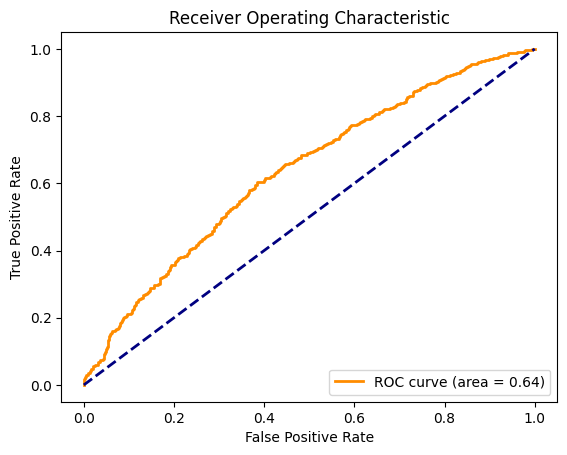

In [118]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [119]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Time series cross-validation (maintains chronological order)
tscv = TimeSeriesSplit(n_splits=5)

model = xgb.XGBClassifier(random_state=42)

# Grid search with time series CV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,  # Use all CPU cores for faster compute
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_}")

# Test on hold-out set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
train_accuracy = best_model.score(X_train, y_train)
print(f"Test accuracy: {test_accuracy}")
print(f"Train accuracy: {train_accuracy}")

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


KeyboardInterrupt: 

## Add other features used in the paper - Micah

### Features From Paper
Wins - Sum
Loss - Sum
Goals For - Sum, Avg, Slope, Projection
Goals Against - ...
Seperate Feature for 5v5
Shots For - Sum, Avg, Slope, Projection
Shots Against - ...
CORSI (shot for - shot against) - sum, avg
CORSI% - ...
Fenwick% (CORSI but not blocked)
CORSI 5v5
CORSI 5v5 close

Face-off For - Sum, Avg, Slope, Projection
Face-off Against- Sum, Avg, Slope, Projection
Hits (Body check) For - Sum, Avg, Slope, Projection
Hits Against - Sum, Avg, Slope, Projection
Penalty Min For - Sum, Avg, Slope, Projection
Penalty Min Against - Sum, Avg, Slope, Projection

Blocks For - Sum, Avg, Slope, Projection
Blocks Against - Sum, Avg, Slope, Projection
Giveaways For - Sum, Avg, Slope, Projection
Giveaways Against - Sum, Avg, Slope, Projection
Takeaways For- Sum, Avg, Slope, Projection
Takeaways Against- Sum, Avg, Slope, Projection
xG For- Sum, Avg, Slope, Projection
xG Against- Sum, Avg, Slope, Projection
5v5
5v5 close

Power Play Opportunity - Slope, Projection
Power Play - Goals Slope, Projection
Power Play Percentage - Percentage
Penalty Kill Opportunities - Slope, Projection
Penalty Kill Goals - scored on during
Penalty Kill Percentage - Percentage when not scored on
Shooting Percentage - goal/shots
Save Percentage - save/shots
PDO - Save + Shoot

Winning Streak - -1, 1

Home - Away as projected


In [120]:
# Create derived features
df_all['loss'] = (df_all['win'] == 0).astype(int)

df_all['shootingPercentageFor'] = (df_all['goalsFor'] / df_all['shotsOnGoalFor'] * 100).fillna(0)
df_all['shootingPercentageAgainst'] = (df_all['goalsAgainst'] / df_all['shotsOnGoalAgainst'] * 100).fillna(0)

df_all['savePercentageFor'] = ((df_all['shotsOnGoalAgainst'] - df_all['goalsAgainst']) / 
                                df_all['shotsOnGoalAgainst'] * 100).fillna(0)
df_all['savePercentageAgainst'] = ((df_all['shotsOnGoalFor'] - df_all['goalsFor']) / 
                                    df_all['shotsOnGoalFor'] * 100).fillna(0)

df_all['pdoFor'] = df_all['shootingPercentageFor'] + df_all['savePercentageFor']
df_all['pdoAgainst'] = df_all['shootingPercentageAgainst'] + df_all['savePercentageAgainst']

df_all['turnoverFor'] = df_all['giveawaysFor']
df_all['turnoverAgainst'] = df_all['giveawaysAgainst']
df_all['turnoverToGiveRatioFor'] = (df_all['takeawaysFor'] / df_all['giveawaysFor']).fillna(0).replace([np.inf, -np.inf], 0)
df_all['turnoverToGiveRatioAgainst'] = (df_all['takeawaysAgainst'] / df_all['giveawaysAgainst']).fillna(0).replace([np.inf, -np.inf], 0)

df_all['corsiFor'] = df_all['shotAttemptsFor']
df_all['corsiAgainst'] = df_all['shotAttemptsAgainst']
df_all['fenwickFor'] = df_all['unblockedShotAttemptsFor']
df_all['fenwickAgainst'] = df_all['unblockedShotAttemptsAgainst']

feature_cols = [
    'team',
    'season',
    'name',
    'gameId',
    'playerTeam',
    'opposingTeam',
    'home_or_away',
    'gameDate',
    'win',
    'loss',
    'goalsFor',
    'goalsAgainst',
    'shotsOnGoalFor',
    'shotsOnGoalAgainst',
    'shotAttemptsFor',
    'shotAttemptsAgainst',
    'corsiFor',
    'corsiAgainst',
    'fenwickFor',
    'fenwickAgainst',
    'faceOffsWonFor',
    'faceOffsWonAgainst',
    'hitsFor',
    'hitsAgainst',
    'penaltiesFor',
    'penaltiesAgainst',
    'penalityMinutesFor',
    'penalityMinutesAgainst',
    'blockedShotAttemptsFor',
    'blockedShotAttemptsAgainst',
    'giveawaysFor',
    'giveawaysAgainst',
    'takeawaysFor',
    'takeawaysAgainst',
    'xGoalsFor',
    'xGoalsAgainst',
    'shootingPercentageFor',
    'shootingPercentageAgainst',
    'savePercentageFor',
    'savePercentageAgainst',
    'pdoFor',
    'pdoAgainst',
    'turnoverFor',
    'turnoverAgainst',
    'turnoverToGiveRatioFor',
    'turnoverToGiveRatioAgainst'
]

# Select features
df_all_select = df_all.loc[:, feature_cols]

In [121]:
# Function to calculate slope for a rolling window
def calculate_slope(series):
    if len(series) < 2 or series.isna().any():
        return np.nan
    x = np.arange(len(series))  # Days/games (0, 1, 2, ...)
    y = series.values
    # Calculate slope using linear regression formula
    slope = np.polyfit(x, y, 1)[0]
    return slope

In [122]:
df_all_select.sort_values(by=['team', 'gameDate'], inplace=True)
df_all_select.reset_index(drop=True, inplace=True)

In [124]:
for col_name in feature_cols:
    if pd.api.types.is_numeric_dtype(df_all_select[col_name]):
        df_all_select[col_name + "_3avg"] = df_all_select.groupby('team')[col_name].rolling(window=3).mean().reset_index(0, drop=True)
        df_all_select[col_name + "_3mean"] = df_all_select.groupby('team')[col_name].rolling(window=3).sum().reset_index(0, drop=True)
        df_all_select[col_name + "_3lm"] = df_all_select.groupby('team')[col_name].rolling(window=3).apply(calculate_slope, raw=False).reset_index(0, drop=True)


C:\Users\the4b\AppData\Local\Temp\ipykernel_15656\1645608313.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all_select[col_name + "_3mean"] = df_all_select.groupby('team')[col_name].rolling(window=3).sum().reset_index(0, drop=True)
C:\Users\the4b\AppData\Local\Temp\ipykernel_15656\1645608313.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all_select[col_name + "_3lm"] = df_all_select.groupby('team')[col_name].rolling(window=3).apply(calculate_slope, raw=False).reset_index(0, drop=True)
C:\Users\the4b\AppData\Local

In [ ]:
rolling_cols = [col for col in df_all_select.columns if col.endswith(('_3avg', '_3mean'))]

cat_cols = ["team", "season", "name", "gameId", "playerTeam", "opposingTeam", "home_or_away", "gameDate", "win"]

Recall Slope Based

Goals
Hits
Penalty Min
Blocks
Giveaways
Takeaways
xG
penalty kill Goal -- Not included
Penalty Kill Op -- Not included

In [134]:
lm_cols = [
'goalsFor_3lm',
'goalsAgainst_3lm',
'hitsFor_3lm',
'hitsAgainst_3lm',
'penalityMinutesFor_3lm',
'penalityMinutesAgainst_3lm',
'blockedShotAttemptsFor_3lm',
'blockedShotAttemptsAgainst_3lm',
'giveawaysFor_3lm',
'giveawaysAgainst_3lm',
'takeawaysFor_3lm',
'takeawaysAgainst_3lm',
'xGoalsFor_3lm',
'xGoalsAgainst_3lm']

#with open("columns.txt", "w") as f:
#    for col in [col for col in df_all_select.columns if col.endswith(('_3lm'))]:
#        f.write(f"{col}\n")

df_roll = df_all_select.loc[:, cat_cols + rolling_cols + lm_cols]

In [136]:
X = df_roll.loc[:,[col for col in df_roll.columns if col.endswith(('_3avg', '_3mean', '_3lm'))]]
y = df_roll['win']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [137]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, 
    min_samples_split=100,
    min_samples_leaf=10,
    random_state=42
)
rf_model.fit(X_train, y_train)

train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.9327068808729918
Test accuracy: 0.9024242424242425


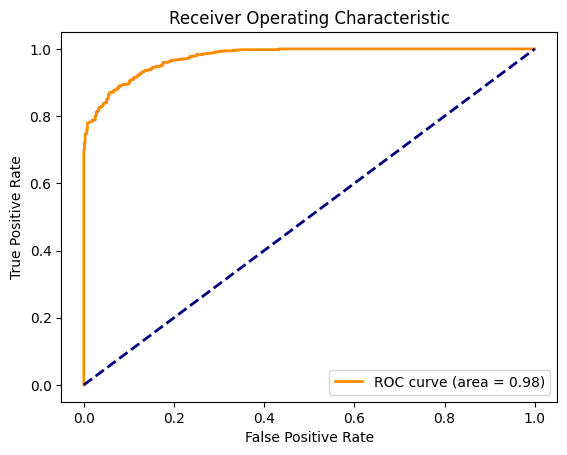

In [138]:
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Define parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Time series cross-validation (maintains chronological order)
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = xgb.XGBClassifier(random_state=42)

# Grid search with time series CV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_}")

# Test on hold-out set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
train_accuracy = best_model.score(X_train, y_train)
print(f"Test accuracy: {test_accuracy}")
print(f"Train accuracy: {train_accuracy}")

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV score: 0.9512836062259956
Test accuracy: 0.9478787878787879
Train accuracy: 0.9721127614428615


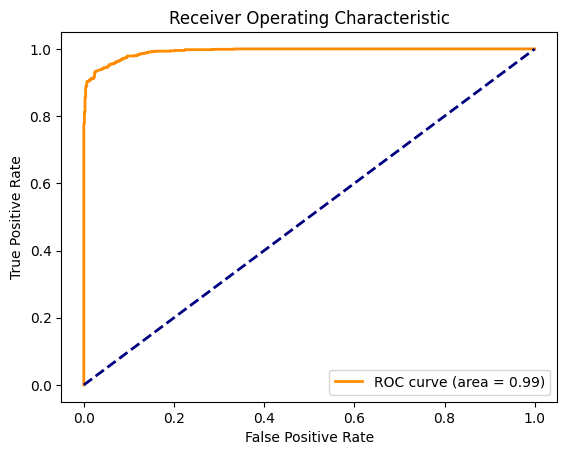

In [140]:
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

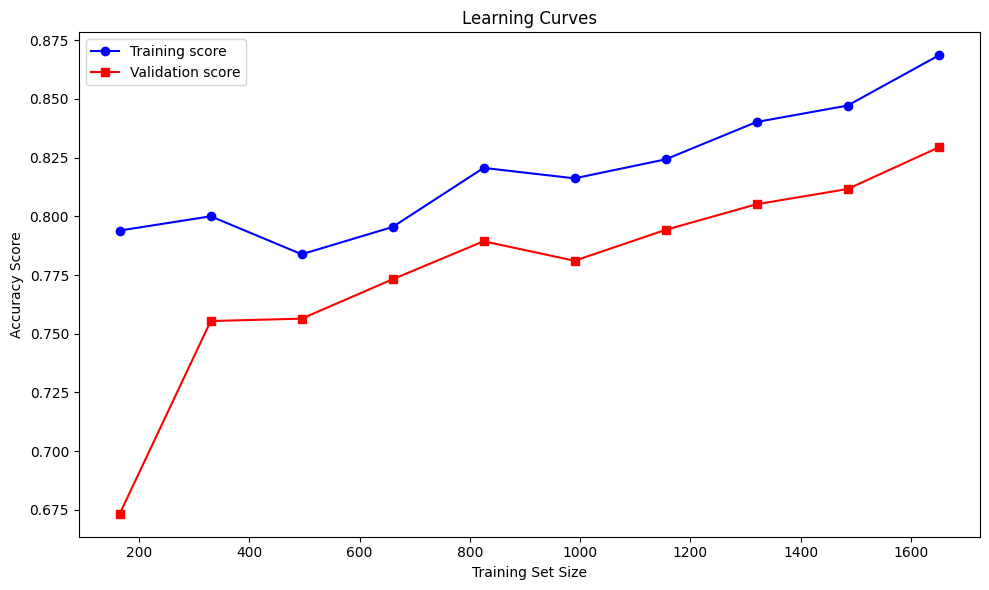

In [143]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plot learning curves showing training and validation scores vs training set size
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, 
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='accuracy',
        verbose=0
    )
    
    # Calculate mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
    
    plt.plot(train_sizes, val_mean, label='Validation score', color='red', marker='s')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title('Learning Curves')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

plot_learning_curve(rf_model, X_train, y_train, cv=tscv)

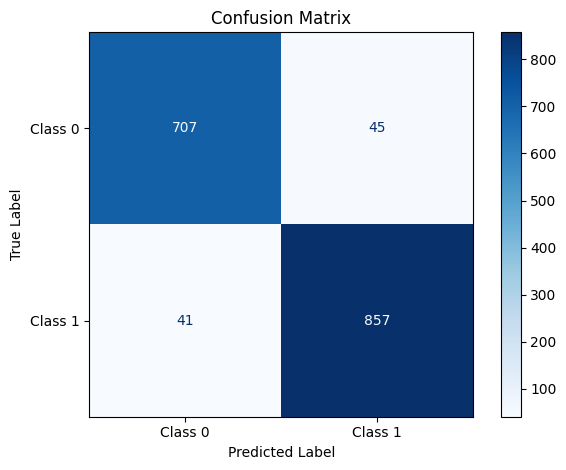

In [145]:
y_pred = best_model.predict(X_test)
class_names = ['Class 0', 'Class 1']
cm = confusion_matrix(y_test, y_pred)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()